Predict Food Image With Food101 Using Model EfficientNet-B0

Source Dataset:
- https://docs.pytorch.org/vision/main/generated/torchvision.datasets.Food101.html

In [97]:
import torch
import torchvision
from torch.utils.data import ConcatDataset, DataLoader, random_split, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

In [98]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [99]:
from pathlib import Path

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


def create_food101_dataloaders(
    root: str,
    transform_train: transforms.Compose,
    transform_test: transforms.Compose,
    batch_size: int,
    num_workers: int = 4,
):

    # Food101 Dataset (split bawaan: "train" dan "test")
    data_train = datasets.Food101(
        root=root,
        split="train",
        download=True,
        transform=transform_train,
    )

    data_test = datasets.Food101(
        root=root,
        split="test",
        download=True,
        transform=transform_test,
    )


    # Check Class Mapping
    print("Food101 Class Mapping (sebagian):")
    print(list(data_train.class_to_idx.items())[:5])

    print("\nJumlah Kelas:", len(data_train.classes))


    img, label = data_train[0]

    print("\nSample Food101:")
    print("Label index :", label)
    print("Class name  :", data_train.classes[label])


    # DataLoader
    train_loader = DataLoader(
        data_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )

    test_loader = DataLoader(
        data_test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )


    # Class names dari dataset
    class_names = data_train.classes


    print("\nDataset Size:")
    print("Food101 Train :", len(data_train))
    print("Food101 Test  :", len(data_test))


    return (
        train_loader,
        test_loader,
        data_train,
        data_test,
        class_names
    )

In [100]:
import torch
import torchvision
from timeit import default_timer as timer
from tqdm.auto import tqdm
from typing import Dict, List, Tuple
from pathlib import Path
from PIL import Image, ImageOps


def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device) -> Tuple[float, float]:

  model.train()

  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(y_pred, dim=1)
    train_acc += (y_pred_class == y).sum().item() / len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)

  return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.dataloader,
              loss_fn: torch.nn.Module,
              device: torch.device) -> Tuple[float, float]:

  model.eval()

  test_loss, test_acc = 0,0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          device: torch.device) -> Dict[str, List]:

  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  train_start_time = timer()

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       device=device)

    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device)

    print(f"epoch : {epoch + 1} | train_loss : {train_loss:.4f} | train_acc : {train_acc:.4f} | test_loss : {test_loss:.4f} | test_acc : {test_acc:.4f}\n")

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  train_end_time = timer()

  print(f"Waktu Yang Dibutuhkan Training : {train_end_time - train_start_time:.3f} seconds")

  return results

def predict(model, image_path, device, transform=None):
    if device is None:
        device = next(model.parameters()).device

    image = Image.open(image_path).convert("RGB")

    if transform is not None:
        image = transform(image)

    image = image.unsqueeze(0).to(device)
    model.to(device)
    model.eval()

    with torch.inference_mode():
        logits = model(image)
        probs = torch.softmax(logits, dim=1)

    pred = probs.argmax(dim=1).item()
    prob = probs.max().item()
    return pred, prob

In [101]:
import torch
from pathlib import Path


def save_checkpoint(
    model: torch.nn.Module,
    model_path: str | Path,
    class_names: list[str],
):
    model_path = Path(model_path)
    model_path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
    }

    torch.save(checkpoint, model_path)

    print(f"[INFO] Checkpoint saved to: {model_path}")

In [102]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

In [103]:
train_loader, test_loader, data_train, data_test, class_names = create_food101_dataloaders(
    root="data",
    transform_train=train_transform,
    transform_test=test_transform,
    batch_size=32,
    num_workers=2
)

Food101 Class Mapping (sebagian):
[('apple_pie', 0), ('baby_back_ribs', 1), ('baklava', 2), ('beef_carpaccio', 3), ('beef_tartare', 4)]

Jumlah Kelas: 101

Sample Food101:
Label index : 23
Class name  : churros

Dataset Size:
Food101 Train : 75750
Food101 Test  : 25250


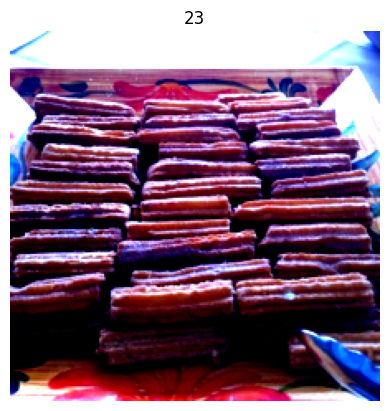

In [104]:
img, label = data_test[0]

plt.imshow(img.permute(1, 2, 0) * 0.5 + 0.5)
plt.title(label)
plt.axis("off")
plt.show()

In [105]:
def test_accuracy(model, dataset, device):
    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    model.eval()

    correct = 0
    total = 0

    with torch.inference_mode():
        for image, label in loader:
            image = image.to(device)
            label = label.to(device)

            logits = model(image)
            pred = logits.argmax(dim=1)

            correct += (pred == label).sum().item()
            total += label.size(0)

    return correct / total

In [106]:
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280, out_features=len(class_names))
)

model = model.to(device)

model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Test Accuracy Before Training

In [107]:
model_acc = test_accuracy(
    model,
    data_test,
    device
)

print(f"Data Accuracy Before: {model_acc:.2%}")

Data Accuracy Before: 0.78%


In [108]:
for param in model.features.parameters():
    param.requires_grad = False

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.classifier.parameters(), lr=1e-3)

Check Accuracy With Minim Datasets

In [109]:
X, y = next(iter(train_loader))

X = X.to(device)

model.eval()

with torch.no_grad():
    out = model(X)

print(out.shape)
print(out[0])

torch.Size([32, 101])
tensor([-0.2141,  0.3771,  0.1634, -0.0155, -0.1176,  0.2281,  0.1425,  0.3229,
         0.0646, -0.2972, -0.1004, -0.0604, -0.2765,  0.2163, -0.2636, -0.0559,
        -0.2696,  0.2590, -0.3767,  0.2849, -0.2922,  0.1079,  0.3770,  0.1952,
        -0.2029, -0.1054,  0.1340, -0.2653,  0.1845, -0.2127,  0.0555, -0.2645,
        -0.1337,  0.3127, -0.3747, -0.0442,  0.1277,  0.1092, -0.3640, -0.3195,
         0.0156, -0.4914, -0.4571, -0.2488,  0.3442,  0.2601,  0.7200,  0.4181,
        -0.1091,  0.4757,  0.2169,  0.3555, -0.0615, -0.3610, -0.2304, -0.4115,
         0.1707,  0.0081, -0.0711, -0.3220,  0.3160, -0.3467, -0.2765, -0.2179,
         0.1537, -0.4093, -0.3187,  0.1719, -0.5144, -0.0125,  0.2654,  0.3000,
         0.0509, -0.0913, -0.0183,  0.3555, -0.0300,  0.2044,  0.4470,  0.1348,
        -0.3073, -0.0293,  0.1468,  0.2100, -0.0906,  0.1251, -0.0864, -0.0558,
         0.2939,  0.1704, -0.0486, -0.2931,  0.0779,  0.4853, -0.0406,  0.4145,
        -0.1036,  

In [110]:
labels = [data_train[i][1] for i in range(100)]

unique_labels = sorted(set(labels))

print("Jumlah kelas:", len(unique_labels))

for label in unique_labels:
    print(label, "->", class_names[label])

Jumlah kelas: 1
23 -> churros


In [111]:
train_indices = torch.randperm(len(data_train))[:100]
test_indices = torch.randperm(len(data_test))[:100]

train_subset = Subset(data_train, train_indices)
test_subset = Subset(data_test, test_indices)

len(train_subset), len(test_subset)

(100, 100)

In [112]:
train_subset_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_subset_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [113]:
results = train(
    model=model,
    train_dataloader=train_subset_loader,
    test_dataloader=test_subset_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=20,
    device=device
)

  0%|          | 0/20 [00:00<?, ?it/s]

epoch : 1 | train_loss : 4.7003 | train_acc : 0.0000 | test_loss : 4.5950 | test_acc : 0.0234

epoch : 2 | train_loss : 4.1284 | train_acc : 0.2422 | test_loss : 4.5863 | test_acc : 0.0234

epoch : 3 | train_loss : 3.8566 | train_acc : 0.2031 | test_loss : 4.6013 | test_acc : 0.0312

epoch : 4 | train_loss : 3.5597 | train_acc : 0.2891 | test_loss : 4.6323 | test_acc : 0.0547

epoch : 5 | train_loss : 3.2098 | train_acc : 0.5391 | test_loss : 4.6915 | test_acc : 0.0469

epoch : 6 | train_loss : 2.9915 | train_acc : 0.6172 | test_loss : 4.7365 | test_acc : 0.0391

epoch : 7 | train_loss : 2.8038 | train_acc : 0.6797 | test_loss : 4.7730 | test_acc : 0.0469

epoch : 8 | train_loss : 2.5572 | train_acc : 0.7578 | test_loss : 4.8118 | test_acc : 0.0469

epoch : 9 | train_loss : 2.3551 | train_acc : 0.8672 | test_loss : 4.8420 | test_acc : 0.0547

epoch : 10 | train_loss : 2.1536 | train_acc : 0.8594 | test_loss : 4.8213 | test_acc : 0.0547

epoch : 11 | train_loss : 2.0638 | train_acc : 0.

Training Large Dataset

In [114]:
for param in model.features.parameters():
    param.requires_grad = False

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.classifier.parameters(), lr=1e-3)

results_stage1 = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=3,          # classifier yang dilatih
    device=device
)

  0%|          | 0/3 [00:00<?, ?it/s]

epoch : 1 | train_loss : 2.7851 | train_acc : 0.3584 | test_loss : 1.7825 | test_acc : 0.5557

epoch : 2 | train_loss : 2.3724 | train_acc : 0.4304 | test_loss : 1.6344 | test_acc : 0.5840

epoch : 3 | train_loss : 2.3045 | train_acc : 0.4439 | test_loss : 1.6085 | test_acc : 0.5883

Waktu Yang Dibutuhkan Training : 1625.662 seconds


In [116]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-4)

results_stage2 = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=5,
    device=device
)

  0%|          | 0/5 [00:00<?, ?it/s]

epoch : 1 | train_loss : 1.0180 | train_acc : 0.7276 | test_loss : 0.6425 | test_acc : 0.8197

epoch : 2 | train_loss : 0.8664 | train_acc : 0.7654 | test_loss : 0.6115 | test_acc : 0.8290

epoch : 3 | train_loss : 0.7697 | train_acc : 0.7897 | test_loss : 0.5935 | test_acc : 0.8353

epoch : 4 | train_loss : 0.6900 | train_acc : 0.8080 | test_loss : 0.5857 | test_acc : 0.8386

epoch : 5 | train_loss : 0.6110 | train_acc : 0.8299 | test_loss : 0.5766 | test_acc : 0.8414

Waktu Yang Dibutuhkan Training : 3071.065 seconds


In [123]:
save_checkpoint(model=model,
                           model_path="models/food_model_efficientnet_b0_trained_experiments.pth",
                           class_names=class_names)

[INFO] Checkpoint saved to: models/food_model_efficientnet_b0_trained_experiments.pth


In [118]:
correct = 0
total = 0

model.eval()

with torch.inference_mode():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Correct : {correct}")
print(f"Total   : {total}")
print(f"Acc     : {correct/total:.4f}")

Correct : 21241
Total   : 25250
Acc     : 0.8412


Result 1

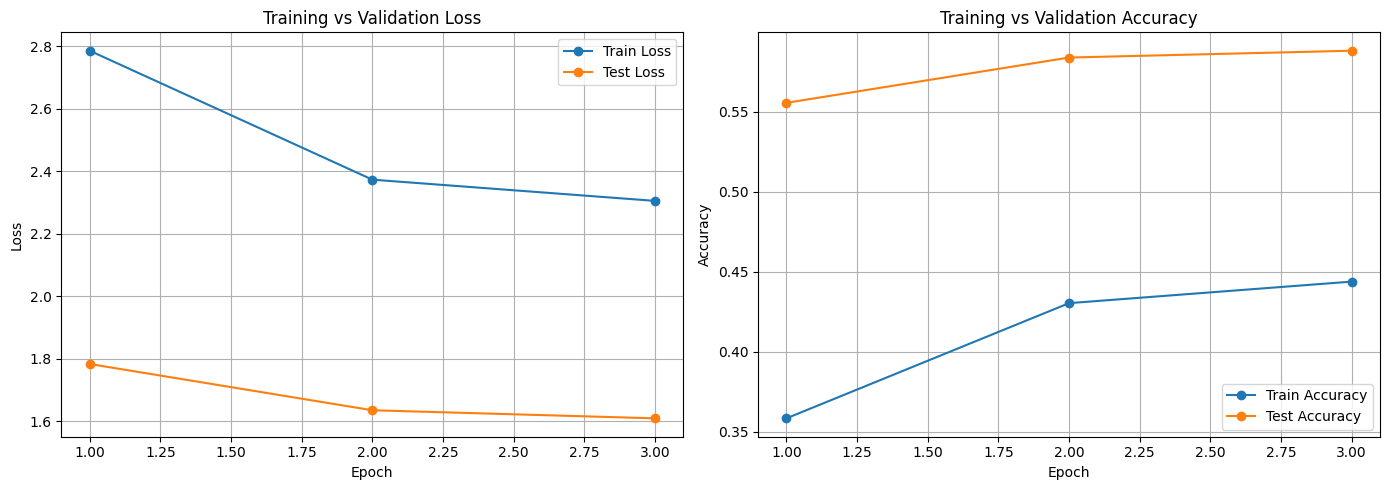

In [119]:
import matplotlib.pyplot as plt

train_loss = results_stage1["train_loss"]
test_loss = results_stage1["test_loss"]
train_acc = results_stage1["train_acc"]
test_acc = results_stage1["test_acc"]

epochs = range(1, len(train_loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax[0].plot(epochs, train_loss, label="Train Loss", marker="o")
ax[0].plot(epochs, test_loss, label="Test Loss", marker="o")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# Accuracy
ax[1].plot(epochs, train_acc, label="Train Accuracy", marker="o")
ax[1].plot(epochs, test_acc, label="Test Accuracy", marker="o")
ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

Result 2

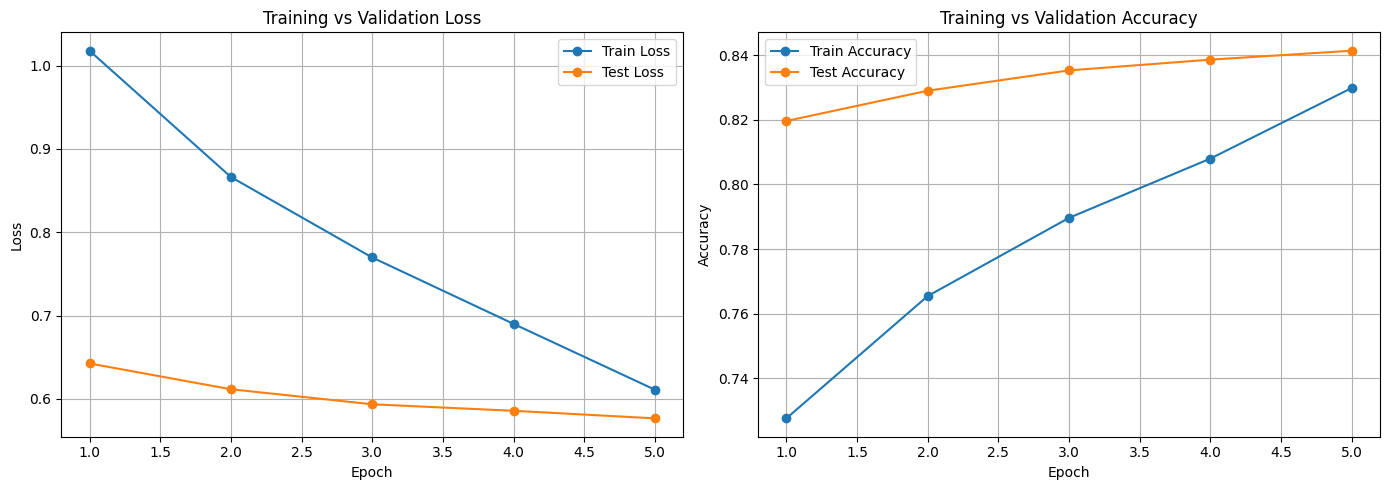

In [120]:
import matplotlib.pyplot as plt

train_loss = results_stage2["train_loss"]
test_loss = results_stage2["test_loss"]
train_acc = results_stage2["train_acc"]
test_acc = results_stage2["test_acc"]

epochs = range(1, len(train_loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax[0].plot(epochs, train_loss, label="Train Loss", marker="o")
ax[0].plot(epochs, test_loss, label="Test Loss", marker="o")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# Accuracy
ax[1].plot(epochs, train_acc, label="Train Accuracy", marker="o")
ax[1].plot(epochs, test_acc, label="Test Accuracy", marker="o")
ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [121]:
model_acc = test_accuracy(
    model,
    data_test,
    device
)

print(f"Data Accuracy After Training : {model_acc:.2%}")

Data Accuracy After Training : 84.12%


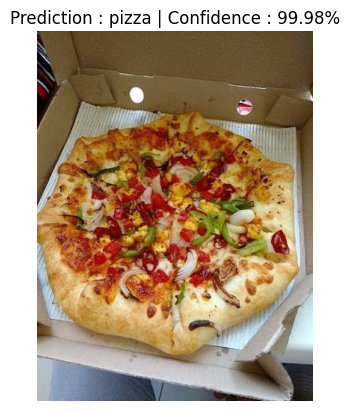

In [128]:
from PIL import Image

path_data = Path("data/")
image_path = path_data / "prediction_image/predict_image1.jpg"

image = Image.open(image_path)

transforms_pred = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

pred, prob = predict(
    model=model,
    image_path=image_path,
    device=device,
    transform=transforms_pred,
)

plt.imshow(image)
plt.title(f"Prediction : {class_names[pred]} | Confidence : {prob:.2%}")
plt.axis("off")
plt.show()